# BIFROST reduction of simulated data

This notebook demonstrates the basic data reduction workflow for BIFROST.
It uses data that was simulated with McStas and a dedicated workflow that can process McStas data.

In [1]:
import numpy as np
import scipp as sc
import sciline
import scippnexus as snx

from ess import bifrost
from ess.bifrost.data import (
    simulated_elastic_incoherent_with_phonon,
    lookup_table_simulation
)
from ess.spectroscopy.types import *

BIFROST NeXus files store detector data in 45 separate NXdetector groups, one per detector triplet.
For the time being, we need to specify the names of these NXdetector groups when creating the workflow.
So load them from the input file:

In [2]:
with snx.File(simulated_elastic_incoherent_with_phonon()) as f:
    detector_names = list(f['entry/instrument'][snx.NXdetector])

Generally, we would use all triplets, but for this example, we only use the first two.
This reduces the size of the data and the time to compute it.

In [3]:
detector_names = detector_names[:2]

Next, construct the workflow which is a [sciline.Pipeline](https://scipp.github.io/sciline/generated/classes/sciline.Pipeline.html) and encodes the entire reduction procedure.
We need to provide a couple of parameters so we can run the workflow:

In [4]:
workflow = bifrost.BifrostSimulationWorkflow(detector_names)
# Set the input file name:
workflow[Filename[SampleRun]] = simulated_elastic_incoherent_with_phonon()
# Set the lookup table for frame unwrapping:
workflow[LookupTableFilename] = lookup_table_simulation()
# Set thresholds to mask wavelength regions with large uncertainties.
# For this example, we do not mask anything:
workflow[LookupTableRelativeErrorThreshold] = {
    'detector': np.inf,
    'normalization_monitor': np.inf,
}
# We need to read many objects from the file,
# keeping it open improves performance: (optional)
workflow[PreopenNeXusFile] = PreopenNeXusFile(True)
# We drop uncertainties where they would otherwise lead to correlations:
workflow[UncertaintyBroadcastMode] = UncertaintyBroadcastMode.drop

Next, draw the workflow as a graph to inspect the steps it will take to reduce the data.

Note the groups where entries are labeled with `(triplet)`. (These labels will be `(dim_0)` if you don't have [Pandas](https://pandas.pydata.org/) installed.)
These groups indicate functions that are applied separately to each detector triplet.

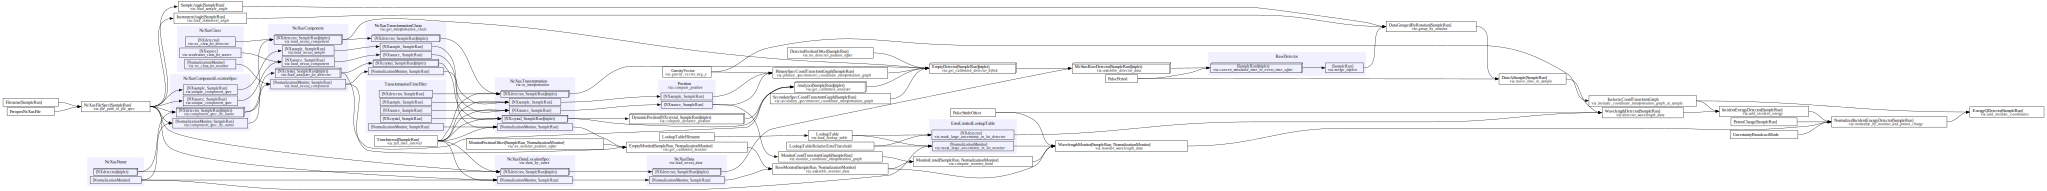

In [5]:
workflow.visualize(EnergyQDetector[SampleRun], compact=True, graph_attr={"rankdir": "LR"})

We are ready to compute the reduced data.
We use the naive scheduler of sciline because it tends to perform better for BIFROST than the [Dask](https://docs.dask.org/en/stable/index.html) scheduler.
But this is optional.

In [6]:
scheduler = sciline.scheduler.NaiveScheduler()
data = workflow.compute(EnergyQDetector[SampleRun], scheduler=scheduler)

The result contains coordinates for the sample table and detector rotation angles `a3` and `a4`, respectively.
It also contains event coordinates for `energy_transfer` and two momentum transfers, one in the lab frame and one in the sample table frame.

In [7]:
data

<scipp.DataArray>
Dimensions: Sizes[arc:2, channel:1, tube:3, length:100, a4:2, a3:176, ]
Coordinates:
* L1                        float64              [m]  ()  161.999
* Ltotal                    float64              [m]  ()  161.999
* a3                        float32            [deg]  (a3)  [0, 1, ..., 178, 179]
* a4                        float32            [deg]  (a4)  [87, 92]
* arc                         int64        <no unit>  (arc, channel)  [0, 1]
* channel                     int64        <no unit>  ()  0
* detector_number             int64        <no unit>  (arc, channel, tube, length)  [1, 2, ..., 4599, 4600]
* secondary_flight_time     float64             [ms]  (arc, channel, a4, tube, length)  [3.198, 3.198, ..., 3.24908, 3.24908]
Data:
                          DataArrayView        <no unit>  (arc, channel, tube, length, a4, a3)  binned data: dim='event', content=DataArray(
          dims=(event: 1034),
          data=float64*counts*s^-1*A^-1],
          coords={'energy_transfer':float64[meV], 'sample_table_momentum_transfer':vector3[1/Å]})

We can plot the counts as a function of energy transfer and $a_3$ by removing the unused dimensions.
As expected, it is independent of $a_3$.

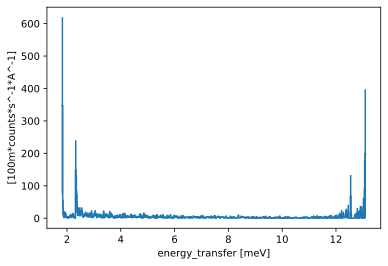

In [8]:
(
    data
    .bins.concat()
    .hist(energy_transfer=500)
).plot()

We can also plot the counts as a function of the momentum transfer in the sample table frame $Q$.
For this, we first need to create a 2D slice in $Q$ and $\Delta E$.
For simplicity, we use the x and z axes or $Q$ (see https://scipp.github.io/scippneutron/user-guide/coordinate-transformations.html for definitions).
But we could use any other normalized, orthogonal vectors in the dot products.

We can make a second plot using one of the projections and the energy transfer.

The plots are a bit coarse because we only used two triplets.

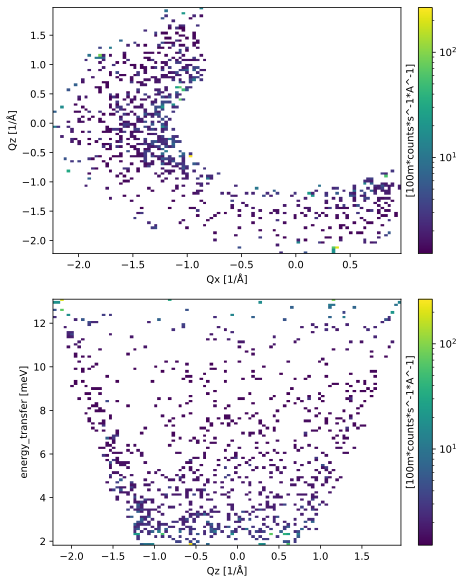

In [9]:
d = data.bins.concat().copy()
x = sc.vector([1, 0, 0])
z = sc.vector([0, 0, 1])
d.bins.coords['Qx'] = sc.dot(x, d.bins.coords['sample_table_momentum_transfer'])
d.bins.coords['Qz'] = sc.dot(z, d.bins.coords['sample_table_momentum_transfer'])
d.hist(Qz=100, Qx=100).plot(norm='log') / d.hist(energy_transfer=100, Qz=100).plot(norm='log')